In [1]:
import geopandas as gpd
import polars as pl
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

In [5]:
# 1. Load the data with Polars
main_path = "/Users/anzony.quisperojas/Library/CloudStorage/Dropbox/sa_fires"
proj_path = f"{main_path}/proj_bureaucrats_farms"
int_path = f"{proj_path}/data_output/intermediate"
file_path = fr"{int_path}/0_master_merge_data_gen.csv"
df = pl.read_csv(file_path, ignore_errors = True)
ghs = pd.read_stata(f"{int_path}/ghs_grid_classification_2000.dta")



In [6]:
ghs_pl = pl.from_pandas(ghs)

# 2. merge (inner join) sobre la grilla, y quedarte solo con is_rural == 1
df = (
    df.join(ghs_pl, on="unique_small_grid_id", how="inner")
      .filter(pl.col("is_rural") == 1)
)

In [7]:

# 2. Collapse (group) to monthly level, summing count
df_monthly = (
    df.group_by(["year", "month"])
      .agg(pl.col("count").sum().alias("count"))
      .sort(["year", "month"])
)

# 3. Create a datetime column for plotting
df_monthly = df_monthly.with_columns(
    pl.datetime(
        df_monthly["year"],
        df_monthly["month"],
        pl.lit(1)  # day=1 for all
    ).alias("date")
)

# 4. Convert to pandas for matplotlib plotting
df_pd = df_monthly.to_pandas()


In [8]:
df_pd['count'] = df_pd['count'] / 1000

In [9]:
df_pd = df_pd.query('year < 2022 | (year == 2022 & month <= 8)')

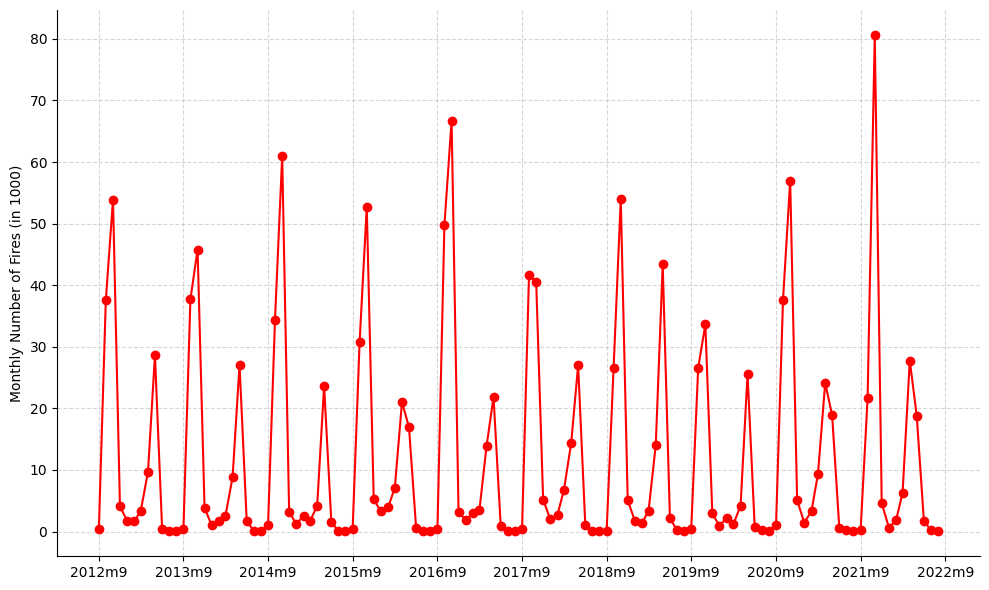

In [10]:
# 5. Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_pd['date'], df_pd['count'], color='red', marker='o', linestyle='-')

# Filter Septembers every 2 years
september_dates = df_pd[
    (df_pd['date'].dt.month == 9)
]['date'].tolist()

# Add 2022m9 if not already included
sep_2022 = pd.Timestamp(year=2022, month=9, day=1)
if sep_2022 not in september_dates:
    september_dates.append(sep_2022)

# Sort to keep chronological order
september_dates = sorted(september_dates)

ax.set_xticks(september_dates)
ax.set_xticklabels([f"{d.year}m{d.month}" for d in september_dates])

# Keep grid lines
ax.grid(True, linestyle='--', alpha=0.5)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Labels and title
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('Monthly Number of Fires (in 1000)')

plt.tight_layout()

# Save as PNG with 300 dpi
plt.savefig(f"{proj_path}/tex/paper/figures/monthly_fires.png", dpi=300, bbox_inches='tight')

plt.show()


In [11]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

# 2) Collapse to monthly (mean for wind directions)
df_monthly = (
    df.group_by(["year", "month"])
      .agg([
          pl.col("rollav_wind_direction_cellid_month").mean().alias("rollav_wdir"),
          pl.col("wind_direction").mean().alias("wdir")
      ])
      .sort(["year", "month"])
      .with_columns(
          pl.datetime(pl.col("year"), pl.col("month"), pl.lit(1)).alias("date")
      )
)

# 3) To pandas for plotting
df_pd = df_monthly.to_pandas()
df_pd = df_pd.query('year < 2022 | (year == 2022 & month <= 8)')


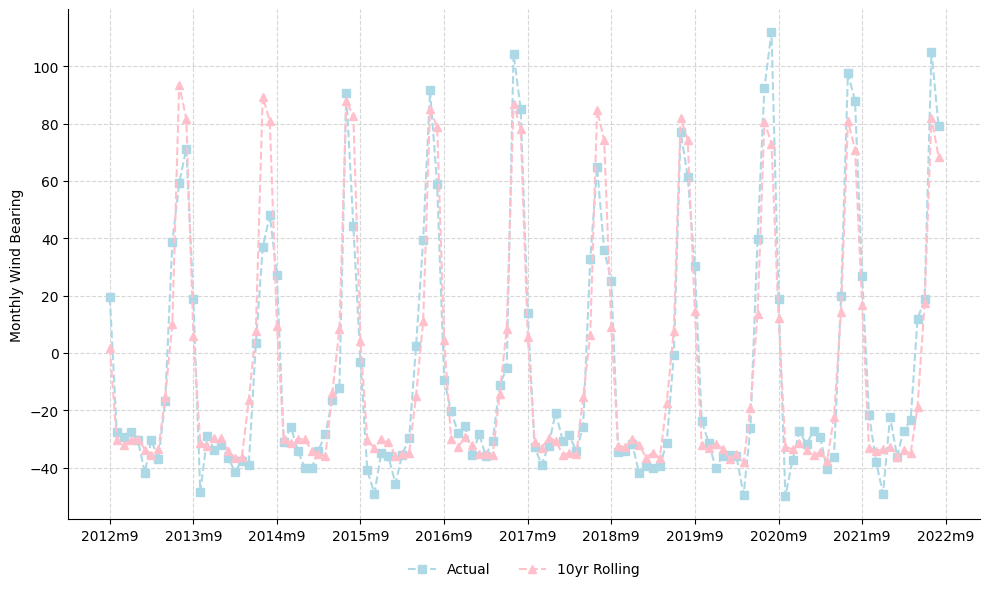

In [12]:
# 4) Build September ticks every 2 years + ensure 2022m9
sep_ticks = df_pd[
    (df_pd["date"].dt.month == 9)
]["date"].tolist()

sep_2022 = pd.Timestamp(2022, 9, 1)
if sep_2022 not in sep_ticks:
    sep_ticks.append(sep_2022)
sep_ticks = sorted(sep_ticks)

# 5) Plot
fig, ax = plt.subplots(figsize=(10, 6))



# Series 2: raw wind direction
ax.plot(
    df_pd["date"], df_pd["wdir"],
    linestyle="--", marker="s", color="lightblue", label="Actual"
)

# Series 1: rolling avg wind direction
ax.plot(
    df_pd["date"], df_pd["rollav_wdir"],
    linestyle="--", marker="^", color="pink", label="10yr Rolling"
)

# X ticks & labels like YYYYm9
ax.set_xticks(sep_ticks)
ax.set_xticklabels([f"{d.year}m{d.month}" for d in sep_ticks])

# Grid (keep), spines (only left/bottom)
ax.grid(True, linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Labels / legend
ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("Monthly Wind Bearing")
# Legend below plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.06),  # Centered, below axis
    ncol=2,
    frameon=False
)

plt.tight_layout()
# If you also want to save:
plt.savefig(f"{proj_path}/tex/paper/figures/monthly_wind_direction.png", dpi=300, bbox_inches="tight")

plt.show()

